In [1]:
import numpy as np
from numba import njit , prange
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from scipy.stats import skew
from scipy.ndimage import uniform_filter1d
from scipy.signal import hilbert
import pandas as pd
from tqdm import tqdm
import progressbar 
import os, json, time, gc, io, contextlib, math
from numba import set_num_threads, get_num_threads
from operator import mod
from itertools import product
from statsmodels.tsa.stattools import adfuller
from itertools import permutations
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
import glob
import imageio.v2 as imageio
from scipy.integrate import solve_ivp
from math import comb
from scipy.interpolate import interp1d
from pathlib import Path
from loguru import logger
import typer
import sys


PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT ))

import moran.methods as methods
import moran.config as config

2026-03-10 14:36:30.718 | INFO     | moran.config:<module>:11 - PROJ_ROOT path is: C:\Users\ah741\Desktop\fitness_waves


In [5]:
n_individuals = 3000
b1_rate = 0.4
d1_rate = 0.6
skip = n_individuals * 10
tmax = n_individuals * 40
lag = 100
indices = np.arange(skip, tmax, lag) 
t_lag = 100
n_out = len(indices) 

In [3]:
trait_values = np.zeros(n_individuals)
All_tv, Main_3D, Clipp, Moments, Moments_right_tail, Moments_left_tail, Hist_counts, Hist_edges = methods.Quad_Sim_V2(b1_rate, 0, d1_rate, 0, tmax, indices, trait_values, nbins=128)
skwl = Main_3D[1, :]
stdl = Main_3D[2, :]
mean_trait_values = Main_3D[0, :]
ALL_b_clip_count = Clipp[0, :]
ALL_d_clip_count = Clipp[1, :]
ALL_b_clip_mass  = Clipp[2, :]
ALL_d_clip_mass  = Clipp[3, :]
ALL_wb_eff_mass  = Clipp[4, :]
ALL_wd_eff_mass  = Clipp[5, :]
ALL_mu1 = Moments[0, :]
ALL_mu2 = Moments[1, :]
ALL_mu3 = Moments[2, :]
ALL_mu4 = Moments[3, :]
ALL_moments_right_tail_1 = Moments_right_tail[0, :]
ALL_moments_right_tail_2 = Moments_right_tail[1, :]
ALL_moments_right_tail_3 = Moments_right_tail[2, :]
ALL_moments_right_tail_4 = Moments_right_tail[3, :]
ALL_moments_left_tail_1 = Moments_left_tail[0, :]
ALL_moments_left_tail_2 = Moments_left_tail[1, :]
ALL_moments_left_tail_3 = Moments_left_tail[2, :]
ALL_moments_left_tail_4 = Moments_left_tail[3, :]

In [4]:


varl = stdl**2
Amp_2D = np.sqrt(skwl**2 + varl)
Phase_2D = np.arctan2(skwl - np.mean(skwl), stdl - np.mean(stdl))
Freq_2D = np.diff(np.unwrap(Phase_2D))
Freq_2D = np.concatenate([Freq_2D[:1], Freq_2D])/(t_lag)*n_individuals

std_Hilbert = hilbert(stdl)
Amp_Hil_std = np.abs(std_Hilbert)
std_Hilbert = hilbert(stdl - np.mean(stdl))
Phase_Hil_std = np.angle(std_Hilbert)
Freq_Hil_std = np.diff(np.unwrap(Phase_Hil_std))
Freq_Hil_std = np.concatenate([Freq_Hil_std[:1], Freq_Hil_std])/(t_lag)*n_individuals

skw_Hilbert = hilbert(skwl)
Amp_Hil_skw = np.abs(skw_Hilbert)
skw_Hilbert = hilbert(skwl - np.mean(skwl))
Phase_Hil_skw = np.angle(skw_Hilbert)
Freq_Hil_skw = np.diff(np.unwrap(Phase_Hil_skw))
Freq_Hil_skw = np.concatenate([Freq_Hil_skw[:1], Freq_Hil_skw])/(t_lag)*n_individuals



rtspeed = np.gradient(mean_trait_values)*n_individuals/(t_lag)
Eff_slope = b1_rate + d1_rate - ALL_b_clip_count*b1_rate - ALL_d_clip_count*d1_rate
NEW_b1_rate = b1_rate * n_individuals / ALL_wb_eff_mass
NEW_d1_rate = d1_rate * n_individuals / ALL_wd_eff_mass
NEW_Eff_slope = NEW_b1_rate + NEW_d1_rate - ALL_b_clip_count*NEW_b1_rate - ALL_d_clip_count*NEW_d1_rate


Mdot = np.gradient(mean_trait_values, 1) * n_individuals / (t_lag)
Vdot = np.gradient(stdl**2, 1) * n_individuals / (t_lag)
Sdot = np.gradient(ALL_mu3, 1) * n_individuals / (t_lag) 

Nb = n_individuals*(1-ALL_b_clip_count)
Nd = n_individuals*(1-ALL_d_clip_count)
mub = (ALL_mu1*n_individuals - ALL_moments_left_tail_1)/Nb
mud = (ALL_mu1*n_individuals - ALL_moments_right_tail_1)/Nd
beff = b1_rate/(1+b1_rate*mub)
deff = d1_rate/(1-d1_rate*mud)
Vb = (ALL_mu2*n_individuals - ALL_moments_left_tail_2)/Nb - mub**2
Vd = (ALL_mu2*n_individuals - ALL_moments_right_tail_2)/Nd - mud**2
Db3 = (ALL_mu3*n_individuals - ALL_moments_left_tail_3)
Dd3 =  (ALL_mu3*n_individuals - ALL_moments_right_tail_3)
Db4 = (ALL_mu4*n_individuals - ALL_moments_left_tail_4)
Dd4 =  (ALL_mu4*n_individuals - ALL_moments_right_tail_4)
Sb = Db3/Nb - mub**3 - 3*mub*Vb
Sd = Dd3/Nd - mud**3 - 3*mud*Vd
Kb = Db4/Nb - mub**4 -6*mub**2*Vb - 4*mub*Sb
Kd = Dd4/Nd - mud**4 -6*mud**2*Vd - 4*mud*Sd

M_dot = (mub - mud)  + beff*Vb + deff*Vd
V_dot = (Vb-Vd) + (mub**2-mud**2)+ beff*(2*mub*Vb+Sb) + deff*(2*mud*Vd+Sd)+1
S_dot = ((Sb-Sd) + 3*(mub*Vb-mud*Vd) + (mub**3-mud**3) + beff*(Kb + 3*(mub**2*Vb+mub*Sb)) + deff*(Kd + 3*(mud**2*Vd+mud*Sd)) + (mub+beff*Vb)) - 3*M_dot*ALL_mu2 - 3*ALL_mu1*V_dot - 3*ALL_mu1**2*M_dot


In [ ]:




# MVBD = np.nanmean(rtspeed / (stdl**2 * ( ( b1_rate + 2*b2_rate*mean_trait_values ) + ( d1_rate + 2*d2_rate*mean_trait_values ) )), axis=1)
if b1_rate + d1_rate == 0 : MVBD_1_ar = MVBD_2_ar = MVBD_4_ar = MVBD_5_ar = MVBD_7_ar = np.nan
else: 
    MVBD_1_ar = rtspeed / (varl * ( b1_rate + d1_rate ))
    MVBD_2_ar = rtspeed / (varl * ( Eff_slope ))
    MVBD_4_ar = rtspeed / (varl * ( NEW_b1_rate + NEW_d1_rate ))
    MVBD_5_ar = rtspeed / (varl * ( NEW_Eff_slope ))
    MVBD_7_ar = rtspeed / (M_dot)



bimodal_flag = np.zeros(n_out, dtype=bool)
hump_left = np.full(n_out, np.nan)
hump_right = np.full(n_out, np.nan)
hump_weight_left = np.full(n_out, np.nan)
hump_weight_right = np.full(n_out, np.nan)

for k in range(0, n_out):
    trait_values = All_tv[k, :].reshape(-1,1)
    gmm1 = GaussianMixture(n_components=1)
    gmm1.fit(trait_values)
    bic1 = gmm1.bic(trait_values)
    gmm2 = GaussianMixture(n_components=2)
    gmm2.fit(trait_values)
    bic2 = gmm2.bic(trait_values)
    mean2 = gmm2.means_.flatten()
    std2 = np.sqrt(gmm2.covariances_.flatten())
    weights2 = gmm2.weights_.flatten()
    sep = abs(mean2[0] - mean2[1]) / np.sqrt(std2[0]**2 + std2[1]**2)
    x_range = np.linspace(Hist_edges[k, 0], Hist_edges[k, -1], 128).reshape(-1,1)
    if bic2 < bic1 and sep > 1.5:
        bimodal_flag[k] = True
        # sort humps left/right
        order = np.argsort(mean2)
        hump_left[k] = mean2[order[0]]
        hump_right[k] = mean2[order[1]]
        hump_weight_left[k] = weights2[order[0]]
        hump_weight_right[k] = weights2[order[1]]

        # logprob = gmm2.score_samples(x_range)
        # pdf_hump = np.exp(logprob)
    # else:
    #     logprob = gmm1.score_samples(x_range)
    #     pdf_hump = np.exp(logprob)

# Detect hump nucleation events
hump_events = np.where((~bimodal_flag[:-1]) & (bimodal_flag[1:]))[0] + 1 

# Waiting times between hump events
if len(hump_events) > 1:
    waiting_times = np.diff(indices[hump_events]) * t_lag
    mean_waiting = np.mean(waiting_times)
    std_waiting = np.std(waiting_times)
else:
    mean_waiting = np.nan
    std_waiting = np.nan

# Where humps nucleate
nucleation_left = hump_left[hump_events]
nucleation_right = hump_right[hump_events]
hump_distance = hump_right[hump_events] - hump_left[hump_events]

# Statistics
mean_nucl_left = np.nanmean(nucleation_left)
mean_nucl_right = np.nanmean(nucleation_right)
std_nucl_left = np.nanstd(nucleation_left)
std_nucl_right = np.nanstd(nucleation_right)
mean_hump_distance = np.nanmean(hump_distance)

In [3]:
All_tv, Main_3D, Clipp, Moments, Moments_right_tail, Moments_left_tail, Theo_M_dot, Hist_counts, Hist_edges = methods.Quad_Sim_tvout(b1_rate, 0, d1_rate, 0, tmax, indices, np.zeros(n_individuals), nbins=64)

In [4]:
lag2 = n_individuals//(lag*100)

skw = Main_3D[1, ::lag2]
std = Main_3D[2, ::lag2]
mean = Main_3D[0, ::lag2]
b_clip_count= Clipp[0, ::lag2]
d_clip_count= Clipp[1, ::lag2]
b_clip_mass= Clipp[2, ::lag2]
d_clip_mass= Clipp[3, ::lag2]
wb_eff_mass= Clipp[4, ::lag2]
wd_eff_mass= Clipp[5, ::lag2]
mu1 = Moments[0, ::lag2]
mu2 = Moments[1, ::lag2]
mu3 = Moments[2, ::lag2]
mu4 = Moments[3, ::lag2]
mu5 = Moments[4, ::lag2]
mu6 = Moments[5, ::lag2]
mu7 = Moments[6, ::lag2]
mu8 = Moments[7, ::lag2]
moments_right_tail_1 = Moments_right_tail[0, ::lag2]
moments_right_tail_2 = Moments_right_tail[1, ::lag2]
moments_right_tail_3 = Moments_right_tail[2, ::lag2]
moments_right_tail_4 = Moments_right_tail[3, ::lag2]
moments_left_tail_1 = Moments_left_tail[0, ::lag2]
moments_left_tail_2 = Moments_left_tail[1, ::lag2]
moments_left_tail_3 = Moments_left_tail[2, ::lag2]
moments_left_tail_4 = Moments_left_tail[3, ::lag2]
Theo_M_dot0 = Theo_M_dot[0, ::lag2]
Theo_M_dot1 = Theo_M_dot[1, ::lag2]
Theo_M_dot2 = Theo_M_dot[2, ::lag2]
Mdot = np.gradient(mean, 1) * n_individuals / (lag*lag2)
Vdot = np.gradient(std**2, 1) * n_individuals / (lag*lag2)
Sdot = np.gradient(mu3, 1) * n_individuals / (lag*lag2) 

Nb = n_individuals*(1-b_clip_count)
Nd = n_individuals*(1-d_clip_count)

mub = (mu1*n_individuals - moments_left_tail_1)/Nb
mud = (mu1*n_individuals - moments_right_tail_1)/Nd
beff = b1_rate/(1+b1_rate*mub)
deff = d1_rate/(1-d1_rate*mud)
Vb = (mu2*n_individuals - moments_left_tail_2)/Nb - mub**2
Vd = (mu2*n_individuals - moments_right_tail_2)/Nd - mud**2
final_M_dot = (mub - mud)  + beff*Vb + deff*Vd

M2dot = np.gradient(mean**2, 1) * n_individuals / lag
Db3 = (mu3*n_individuals - moments_left_tail_3)
Dd3 =  (mu3*n_individuals - moments_right_tail_3)

Db4 = (mu4*n_individuals - moments_left_tail_4)
Dd4 =  (mu4*n_individuals - moments_right_tail_4)

Sb = Db3/Nb - mub**3 - 3*mub*Vb
Sd = Dd3/Nd - mud**3 - 3*mud*Vd

Kb = Db4/Nb - mub**4 -6*mub**2*Vb - 4*mub*Sb
Kd = Dd4/Nd - mud**4 -6*mud**2*Vd - 4*mud*Sd

Vdot_approx = (Vb-Vd) + (mub**2-mud**2)+ beff*(2*mub*Vb+Sb) + deff*(2*mud*Vd+Sd)+1
Sdotappr = ((Sb-Sd) + 3*(mub*Vb-mud*Vd) + (mub**3-mud**3) + beff*(Kb + 3*(mub**2*Vb+mub*Sb)) + deff*(Kd + 3*(mud**2*Vd+mud*Sd)) + (mub+beff*Vb)) - 3*final_M_dot*mu2 - 3*mu1*Vdot_approx - 3*mu1**2*final_M_dot

In [5]:
Main_3D.shape

(3, 3000)

In [ ]:
methods.save_hist_frames_hump(All_tv, Main_3D, indices, Hist_counts, Hist_edges, lag, n_individuals, "C:/Results/Fitnesswaves/Hist/", "hist", histskip=30)

In [12]:
methods.make_video("C:/Results/Fitnesswaves/Hist/", "hist", frame_duration=0.1)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1050, 1500) to (1056, 1504) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# generate synthetic data

data1 = np.random.normal(0, 0.5, 1000)
data2 = np.random.normal(3, 1.0, 10000)

data = np.concatenate([data1, data2])
data = data.reshape(-1,1)

# fit GMM
gmm = GaussianMixture(n_components=2)
gmm.fit(data)

# parameters
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_

print("means:", means)
print("stds:", stds)
print("weights:", weights)

means: [1.33986862 3.22859239]
stds: [1.21390441 0.88421285]
weights: [0.26798658 0.73201342]


In [12]:
data = np.concatenate([data1, data2])
dataa = data.reshape(-1,1)

In [14]:
dataa.shape

(11000, 1)

In [59]:
gmm.covariances_.flatten()

array([0.78008565, 1.56247519])

In [60]:
gmm.means_.flatten()

array([3.21327241, 1.27065063])

In [66]:
logprob = gmm.score_samples(data)
pdf = np.exp(logprob)

In [67]:
pdf.shape

(11000,)

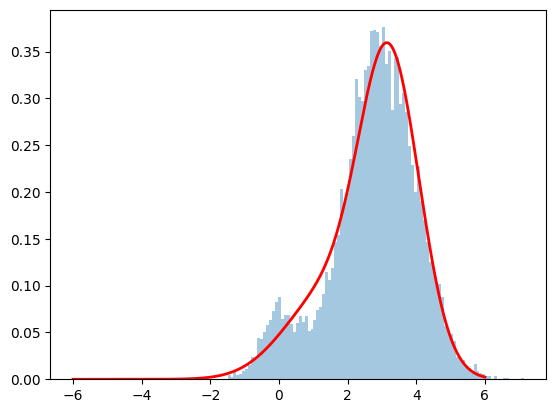

In [70]:
x = np.linspace(-6,6,1000).reshape(-1,1)

logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

plt.hist(data, bins=100, density=True, alpha=0.4)

plt.plot(x, pdf, 'r', lw=2)

plt.show()

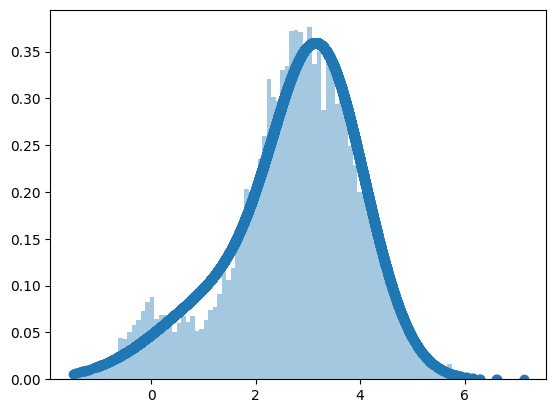

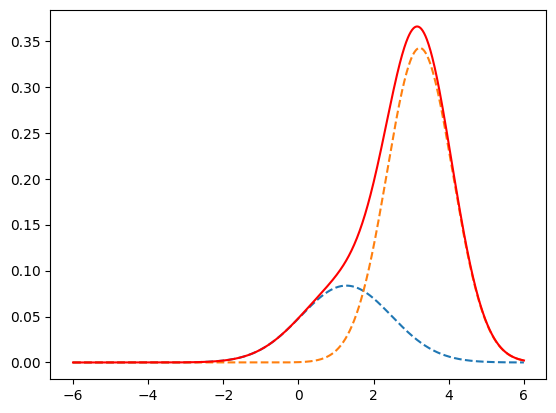

In [39]:
from scipy.stats import norm

x = np.linspace(-6,6,1000)

for i in range(2):
    plt.plot(
        x,
        weights[i]*norm.pdf(x, means[i], stds[i]),
        '--'
    )

plt.plot(x, pdf, 'r')
plt.show()

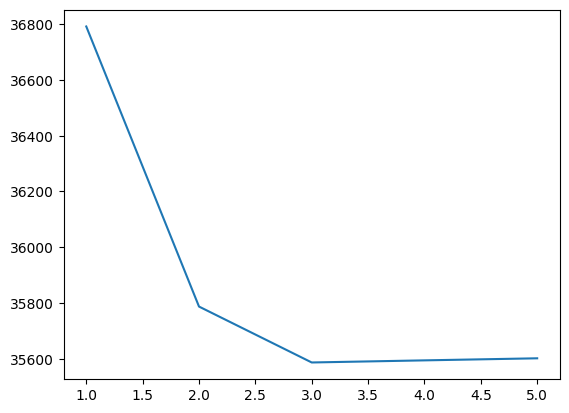

In [41]:
bics = []
for k in range(1,6):
    gmm = GaussianMixture(n_components=k)
    gmm.fit(data)
    bics.append(gmm.bic(data))

plt.plot(range(1,6), bics)
plt.show()

In [42]:
bics

[np.float64(36791.868240000586),
 np.float64(35787.063079778294),
 np.float64(35586.448600938485),
 np.float64(35594.03460414795),
 np.float64(35601.42327938343)]

In [25]:
from scipy.stats import norm

def gaussian_overlap(mu1, s1, mu2, s2):

    x = np.linspace(
        min(mu1-4*s1, mu2-4*s2),
        max(mu1+4*s1, mu2+4*s2),
        10000
    )

    p1 = norm.pdf(x, mu1, s1)
    p2 = norm.pdf(x, mu2, s2)

    overlap = np.trapezoid(np.minimum(p1, p2), x)

    return overlap

In [44]:
ovl = gaussian_overlap(means[0], stds[0], means[1], stds[1])
print("Overlap =", ovl)

Overlap = 0.3387218289425539


In [27]:
def separation_metric(mu1,s1,mu2,s2):
    return abs(mu1-mu2)/np.sqrt(s1**2+s2**2)

In [43]:
separation_metric(means[0], stds[0], means[1], stds[1])

np.float64(1.3169832170383524)